In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [10]:
df = pd.read_csv("C:\\code files\\credit-card-fraud-detection\\data\\raw\\creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.00,-1.36,-0.07,2.54,1.38,-0.34,0.46,0.24,0.10,0.36,0.09,-0.55,-0.62,-0.99,-0.31,1.47,-0.47,0.21,0.03,0.40,0.25,-0.02,0.28,-0.11,0.07,0.13,-0.19,0.13,-0.02,149.62,0
1,0.00,1.19,0.27,0.17,0.45,0.06,-0.08,-0.08,0.09,-0.26,-0.17,1.61,1.07,0.49,-0.14,0.64,0.46,-0.11,-0.18,-0.15,-0.07,-0.23,-0.64,0.10,-0.34,0.17,0.13,-0.01,0.01,2.69,0
2,1.00,-1.36,-1.34,1.77,0.38,-0.50,1.80,0.79,0.25,-1.51,0.21,0.62,0.07,0.72,-0.17,2.35,-2.89,1.11,-0.12,-2.26,0.52,0.25,0.77,0.91,-0.69,-0.33,-0.14,-0.06,-0.06,378.66,0
3,1.00,-0.97,-0.19,1.79,-0.86,-0.01,1.25,0.24,0.38,-1.39,-0.05,-0.23,0.18,0.51,-0.29,-0.63,-1.06,-0.68,1.97,-1.23,-0.21,-0.11,0.01,-0.19,-1.18,0.65,-0.22,0.06,0.06,123.50,0
4,2.00,-1.16,0.88,1.55,0.40,-0.41,0.10,0.59,-0.27,0.82,0.75,-0.82,0.54,1.35,-1.12,0.18,-0.45,-0.24,-0.04,0.80,0.41,-0.01,0.80,-0.14,0.14,-0.21,0.50,0.22,0.22,69.99,0


In [12]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 284,807
Columns: 31
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-nul

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,"284,807.00","94,813.86","47,488.15",0.00,"54,201.50","84,692.00","139,320.50","172,792.00"
V1,"284,807.00",0.00,1.96,-56.41,-0.92,0.02,1.32,2.45
V2,"284,807.00",0.00,1.65,-72.72,-0.60,0.07,0.80,22.06
V3,"284,807.00",-0.00,1.52,-48.33,-0.89,0.18,1.03,9.38
V4,"284,807.00",0.00,1.42,-5.68,-0.85,-0.02,0.74,16.88
V5,"284,807.00",0.00,1.38,-113.74,-0.69,-0.05,0.61,34.80
V6,"284,807.00",0.00,1.33,-26.16,-0.77,-0.27,0.40,73.30
V7,"284,807.00",-0.00,1.24,-43.56,-0.55,0.04,0.57,120.59
V8,"284,807.00",0.00,1.19,-73.22,-0.21,0.02,0.33,20.01
V9,"284,807.00",-0.00,1.10,-13.43,-0.64,-0.05,0.60,15.59


In [14]:
total_transactions = len(df)

fraud_transactions = (df["Class"] == 1).sum()
legitimate_transactions = (df["Class"] == 0).sum()

fraud_rate = fraud_transactions / total_transactions * 100

total_transaction_amount = df["Amount"].sum()
fraud_transaction_amount = df.loc[df["Class"] == 1, "Amount"].sum()

average_transaction_amount = df["Amount"].mean()
median_transaction_amount = df["Amount"].median()

print("========== FRAUD ANALYTICS KPIs ==========")
print(f"Total Transactions        : {total_transactions:,}")
print(f"Legitimate Transactions   : {legitimate_transactions:,}")
print(f"Fraud Transactions        : {fraud_transactions:,}")
print(f"Fraud Rate                : {fraud_rate:.4f}%")
print(f"Total Transaction Amount  : ${total_transaction_amount:,.2f}")
print(f"Fraud Transaction Amount  : ${fraud_transaction_amount:,.2f}")
print(f"Average Transaction       : ${average_transaction_amount:,.2f}")
print(f"Median Transaction        : ${median_transaction_amount:,.2f}")

========== FRAUD ANALYTICS KPIs ==========
Total Transactions        : 284,807
Legitimate Transactions   : 284,315
Fraud Transactions        : 492
Fraud Rate                : 0.1727%
Total Transaction Amount  : $25,162,590.01
Fraud Transaction Amount  : $60,127.97
Average Transaction       : $88.35
Median Transaction        : $22.00


In [15]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Legitimate Transactions",
        "Fraud Transactions",
        "Fraud Rate (%)",
        "Total Transaction Amount",
        "Fraud Transaction Amount",
        "Average Transaction Amount",
        "Median Transaction Amount"
    ],
    "Value": [
        total_transactions,
        legitimate_transactions,
        fraud_transactions,
        fraud_rate,
        total_transaction_amount,
        fraud_transaction_amount,
        average_transaction_amount,
        median_transaction_amount
    ]
})

kpi_summary

,Metric,Value
0,Total Transactions,"284,807.00"
1,Legitimate Transactions,"284,315.00"
2,Fraud Transactions,492.00
3,Fraud Rate (%),0.17
4,Total Transaction Amount,"25,162,590.01"
5,Fraud Transaction Amount,"60,127.97"
6,Average Transaction Amount,88.35
7,Median Transaction Amount,22.00


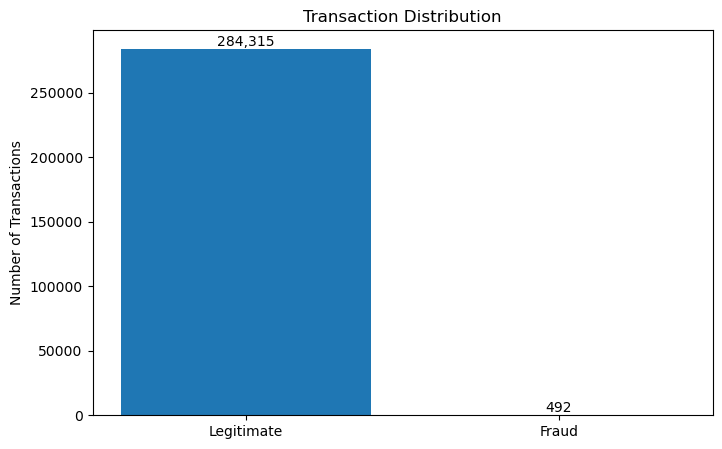

In [16]:
class_counts = df["Class"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    ["Legitimate", "Fraud"],
    class_counts.values
)

plt.title("Transaction Distribution")
plt.ylabel("Number of Transactions")

for i, value in enumerate(class_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

## Key Finding

The dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of total transactions. This highlights the importance of monitoring fraud rate and fraud-specific metrics rather than relying on overall transaction volume or accuracy alone.

## Transaction Amount Analysis

Transaction amount is analyzed to identify whether fraudulent activity is concentrated within specific transaction-value ranges.

In [17]:
# Create transaction amount buckets

bins = [0, 50, 100, 250, 500, float("inf")]
labels = ["0-50", "50-100", "100-250", "250-500", "500+"]

df["Amount_Bucket"] = pd.cut(
    df["Amount"],
    bins=bins,
    labels=labels,
    right=False
)

amount_analysis = df.groupby("Amount_Bucket", observed=False).agg(
    total_transactions=("Class", "count"),
    fraud_transactions=("Class", "sum"),
    total_amount=("Amount", "sum")
)

amount_analysis["fraud_rate"] = (
    amount_analysis["fraud_transactions"]
    / amount_analysis["total_transactions"]
    * 100
)

amount_analysis

,total_transactions,fraud_transactions,total_amount,fraud_rate
Amount_Bucket,,,,
0-50,189704,305,"2,679,438.23",0.16
50-100,37718,57,"2,709,959.87",0.15
100-250,34482,56,"5,377,195.11",0.16
250-500,13411,39,"4,605,333.25",0.29
500+,9492,35,"9,790,663.55",0.37


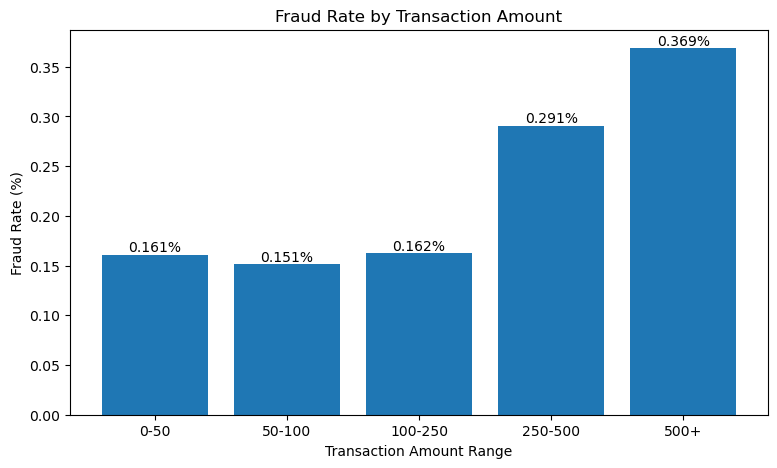

In [18]:
plt.figure(figsize=(9, 5))

plt.bar(
    amount_analysis.index.astype(str),
    amount_analysis["fraud_rate"]
)

plt.title("Fraud Rate by Transaction Amount")
plt.xlabel("Transaction Amount Range")
plt.ylabel("Fraud Rate (%)")

for i, value in enumerate(amount_analysis["fraud_rate"]):
    plt.text(
        i,
        value,
        f"{value:.3f}%",
        ha="center",
        va="bottom"
    )

plt.show()

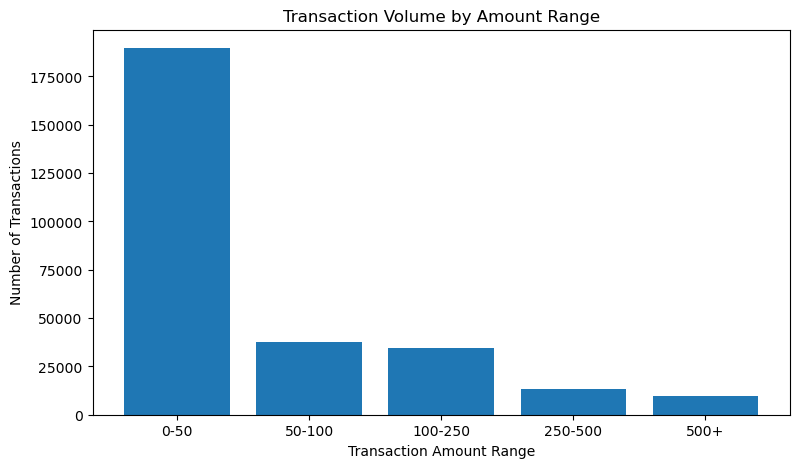

In [19]:
plt.figure(figsize=(9, 5))

plt.bar(
    amount_analysis.index.astype(str),
    amount_analysis["total_transactions"]
)

plt.title("Transaction Volume by Amount Range")
plt.xlabel("Transaction Amount Range")
plt.ylabel("Number of Transactions")

plt.show()

## Key Finding

Fraud risk varies across transaction-value segments. While most transactions fall within the 0–50 range, higher-value transactions show substantially higher fraud rates.

The 500+ transaction segment has the highest observed fraud rate at 0.369%, compared with the overall fraud rate of approximately 0.17%. This suggests that transaction amount can be useful as a risk-monitoring dimension.

## Time-Based Fraud Analysis

Transaction timestamps are analyzed to identify temporal patterns in transaction activity and fraud risk.

In [20]:
# Convert elapsed transaction time into hour of day

df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

df[["Time", "Hour", "Class"]].head()

,Time,Hour,Class
0,0.00,0,0
1,0.00,0,0
2,1.00,0,0
3,1.00,0,0
4,2.00,0,0


In [21]:
hourly_analysis = df.groupby("Hour").agg(
    total_transactions=("Class", "count"),
    fraud_transactions=("Class", "sum")
)

hourly_analysis["fraud_rate"] = (
    hourly_analysis["fraud_transactions"]
    / hourly_analysis["total_transactions"]
    * 100
)

hourly_analysis

,total_transactions,fraud_transactions,fraud_rate
Hour,,,
0,7695,6,0.08
1,4220,10,0.24
2,3328,57,1.71
3,3492,17,0.49
4,2209,23,1.04
5,2990,11,0.37
6,4101,9,0.22
7,7243,23,0.32
8,10276,9,0.09


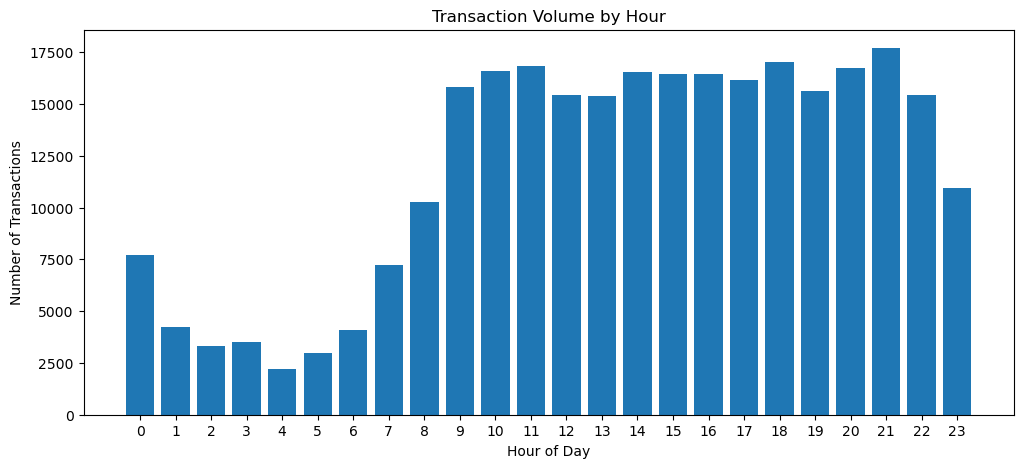

In [22]:
plt.figure(figsize=(12, 5))

plt.bar(
    hourly_analysis.index,
    hourly_analysis["total_transactions"]
)

plt.title("Transaction Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.xticks(range(24))

plt.show()

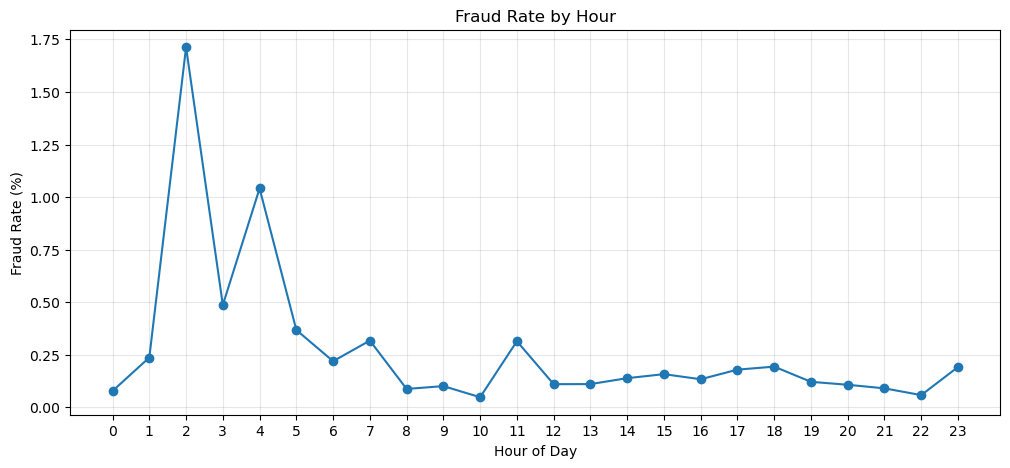

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_analysis.index,
    hourly_analysis["fraud_rate"],
    marker="o"
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()

In [24]:
top_fraud_hours = hourly_analysis.sort_values(
    "fraud_rate",
    ascending=False
).head(5)

top_fraud_hours

,total_transactions,fraud_transactions,fraud_rate
Hour,,,
2,3328,57,1.71
4,2209,23,1.04
3,3492,17,0.49
5,2990,11,0.37
7,7243,23,0.32


## Key Finding

Fraud risk varies across transaction hours. The 2 AM segment records the highest observed fraud rate at 1.71%, compared with the overall fraud rate of approximately 0.17%.

This indicates that transaction time can be used as a useful risk-monitoring dimension, with certain early-morning periods exhibiting elevated fraud rates in the dataset.

In [25]:
risk_analysis = df.groupby(
    ["Hour", "Amount_Bucket"],
    observed=False
).agg(
    total_transactions=("Class", "count"),
    fraud_transactions=("Class", "sum")
)

risk_analysis["fraud_rate"] = (
    risk_analysis["fraud_transactions"]
    / risk_analysis["total_transactions"]
    * 100
)

risk_analysis = risk_analysis.reset_index()

risk_analysis.sort_values(
    "fraud_rate",
    ascending=False
).head(10)

,Hour,Amount_Bucket,total_transactions,fraud_transactions,fraud_rate
14,2,500+,72,2,2.78
13,2,250-500,93,2,2.15
36,7,50-100,957,20,2.09
10,2,0-50,2504,44,1.76
29,5,500+,59,1,1.69
22,4,100-250,185,3,1.62
12,2,100-250,325,5,1.54
24,4,500+,76,1,1.32
4,0,500+,159,2,1.26
118,23,250-500,407,5,1.23


In [26]:
high_risk_segments = risk_analysis[
    risk_analysis["total_transactions"] >= 100
].sort_values(
    "fraud_rate",
    ascending=False
)

high_risk_segments.head(10)

,Hour,Amount_Bucket,total_transactions,fraud_transactions,fraud_rate
36,7,50-100,957,20,2.09
10,2,0-50,2504,44,1.76
22,4,100-250,185,3,1.62
12,2,100-250,325,5,1.54
4,0,500+,159,2,1.26
118,23,250-500,407,5,1.23
11,2,50-100,334,4,1.20
20,4,0-50,1657,18,1.09
34,6,500+,105,1,0.95
94,18,500+,471,4,0.85


## Combined Risk Segmentation

Combining transaction amount and transaction hour reveals specific segments with elevated fraud rates.

The highest observed segment with at least 100 transactions is the 50–100 amount range during hour 7, with a fraud rate of 2.09%. This is substantially higher than the overall fraud rate of 0.17%.

This type of segmentation can support targeted transaction monitoring by prioritizing combinations of temporal and transaction-value characteristics associated with elevated historical fraud rates.